In [95]:
!pip install simpy

# Message Queue Processing Simulation with SimPy

This notebook models a discrete-event simulation for a queue of **200,000 messages** and **20 threads/workers** (default configuration).

Each worker pulls one message, processes it, and then takes the next one. Processing time for a single message is defined by a distribution with the following parameters:

- 50th percentile (Median): **15.0 seconds**
- 95th percentile: **45.0 seconds**

Resulting metrics calculated include:

- Throughput (messages per second and minute) for the whole system;
- Individual worker throughput;
- Total time elapsed to process all messages;
- Processing speed charts over time.

In [96]:
import math
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import simpy

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.3f}".format)

## Simulation Parameters

A log-normal distribution is used for processing time. This is suitable for such tasks because time is always positive, and the long right tail naturally describes occasional slow processing tasks.

Distribution parameters are calculated to match the specified percentiles:

- `median = exp(mu) = 15.0`
- `p95 = exp(mu + sigma * z95) = 45.0`, where `z95 ≈ 1.64485`

In [97]:
@dataclass(frozen=True)
class SimulationConfig:
    messages: int = 120_000
    workers: int = 1
    median_seconds: float = 1.0
    p95_seconds: float = 5.0
    random_seed: int = 42


config = SimulationConfig()

Z95 = 1.6448536269514722
lognormal_mu = math.log(config.median_seconds)
lognormal_sigma = math.log(config.p95_seconds / config.median_seconds) / Z95

print(f"mu: {lognormal_mu:.4f}")
print(f"sigma: {lognormal_sigma:.4f}")
print(f"theoretical median: {math.exp(lognormal_mu):.3f} sec")
print(f"theoretical p95: {math.exp(lognormal_mu + lognormal_sigma * Z95):.3f} sec")
print(f"theoretical mean: {math.exp(lognormal_mu + 0.5 * lognormal_sigma**2):.3f} sec")

mu: 0.0000
sigma: 0.9785
theoretical median: 1.000 sec
theoretical p95: 5.000 sec
theoretical mean: 1.614 sec


## SimPy Model

The model uses `simpy.Store` as a message queue. A worker waits for a message, records the start time, executes `env.timeout(processing_time)`, and then records completion.

In [98]:
def sample_processing_time(rng: np.random.Generator) -> float:
    return float(rng.lognormal(mean=lognormal_mu, sigma=lognormal_sigma))


def worker(env: simpy.Environment, worker_id: int, queue: simpy.Store, rng: np.random.Generator, records: list[dict]):
    while True:
        message_id = yield queue.get()
        if message_id is None:
            break

        start_time = env.now
        duration = sample_processing_time(rng)
        yield env.timeout(duration)
        finish_time = env.now

        records.append(
            {
                "message_id": message_id,
                "worker_id": worker_id,
                "start_time": start_time,
                "finish_time": finish_time,
                "duration": duration,
            }
        )


def run_simulation(config: SimulationConfig) -> pd.DataFrame:
    env = simpy.Environment()
    queue = simpy.Store(env)
    rng = np.random.default_rng(config.random_seed)
    records: list[dict] = []

    # Для 200k сообщений список в памяти небольшой, а Store делает модель явной и читаемой.
    queue.items = list(range(config.messages)) + [None] * config.workers

    for worker_id in range(config.workers):
        env.process(worker(env, worker_id, queue, rng, records))

    env.run()

    result = pd.DataFrame.from_records(records)
    return result.sort_values("finish_time", ignore_index=True)


results = run_simulation(config)
results.head()

,message_id,worker_id,start_time,finish_time,duration
0,0,0,0.000,1.347,1.347
1,1,0,1.347,1.709,0.361
2,2,0,1.709,3.793,2.084
3,3,0,3.793,6.303,2.510
4,4,0,6.303,6.451,0.148


## Verification of Processing Time Distribution


In [99]:
duration_stats = results["duration"].describe(percentiles=[0.5, 0.95, 0.99]).to_frame("seconds")
duration_stats

,seconds
count,120000.000
mean,1.619
std,2.124
min,0.014
50%,0.991
95%,5.031
99%,9.989
max,134.212


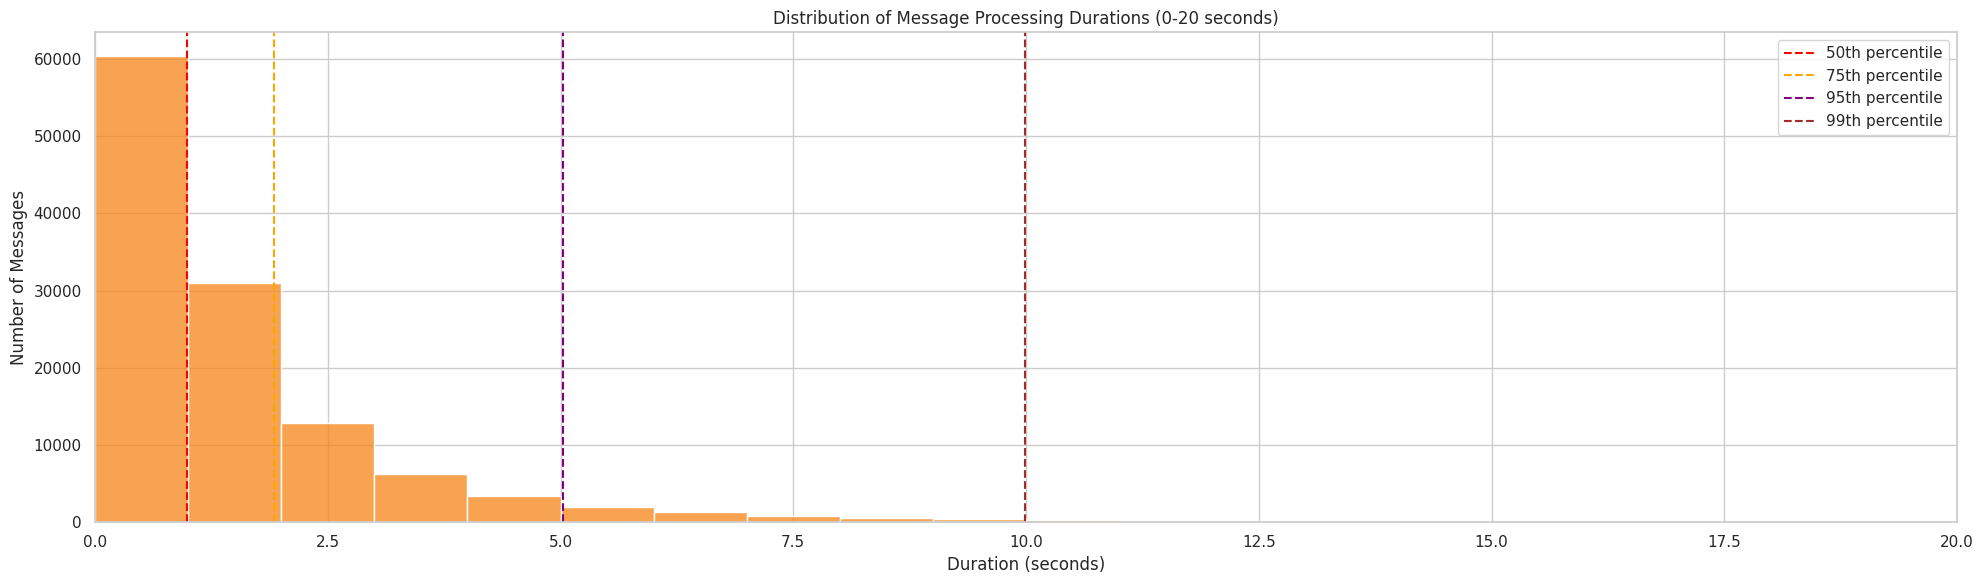

In [112]:
p50 = results["duration"].quantile(0.50)
p75 = results["duration"].quantile(0.75)
p95 = results["duration"].quantile(0.95)
p99 = results["duration"].quantile(0.99)

# Dynamically determine max x-axis limit and bin size
# Use a value slightly beyond the 99th percentile, ensuring it's at least 20 seconds
max_x_limit = max(20, np.ceil(p99 * 1.2))
bins = np.arange(0, max_x_limit + 1, 1) # 1-second bins up to the dynamic max_x_limit

fig, ax = plt.subplots(figsize=(20, 6))
sns.histplot(results["duration"], bins=bins, color="#F58518", ax=ax)
ax.axvline(p50, color='red', linestyle='--', label='50th percentile')
ax.axvline(p75, color='orange', linestyle='--', label='75th percentile')
ax.axvline(p95, color='purple', linestyle='--', label='95th percentile')
ax.axvline(p99, color='brown', linestyle='--', label='99th percentile')
ax.set_title(f"Distribution of Message Processing Durations (0-{int(max_x_limit)} seconds)") # Dynamic title
ax.set_xlabel("Duration (seconds)")
ax.set_ylabel("Number of Messages")
ax.set_xlim(0, max_x_limit) # Set dynamic x-axis limit
ax.legend()
plt.tight_layout()
plt.show()

## Final Throughput and Total Processing Time

In [101]:
total_messages = len(results)
total_time_seconds = results["finish_time"].max()
total_time_minutes = total_time_seconds / 60
total_time_hours = total_time_seconds / 3600

overall_messages_per_second = total_messages / total_time_seconds
overall_messages_per_minute = overall_messages_per_second * 60

summary = pd.DataFrame(
    [
        {"metric": "messages", "value": total_messages},
        {"metric": "total_time_seconds", "value": total_time_seconds},
        {"metric": "total_time_minutes", "value": total_time_minutes},
        {"metric": "total_time_hours", "value": total_time_hours},
        {"metric": "all_workers_messages_per_second", "value": overall_messages_per_second},
        {"metric": "all_workers_messages_per_minute", "value": overall_messages_per_minute},
    ]
)

summary

,metric,value
0,messages,120000.000
1,total_time_seconds,194261.328
2,total_time_minutes,3237.689
3,total_time_hours,53.961
4,all_workers_messages_per_second,0.618
5,all_workers_messages_per_minute,37.063


## Individual Worker Throughput

`messages_per_second_total_window` calculates the average speed of a worker over the entire simulation interval. This is useful for comparison with the total system speed.

`messages_per_second_active_window` calculates the speed only during the active time of a specific worker, from their first start to their last finish.

In [102]:
worker_summary = (
    results.groupby("worker_id")
    .agg(
        messages=("message_id", "count"),
        first_start=("start_time", "min"),
        last_finish=("finish_time", "max"),
        mean_duration=("duration", "mean"),
        median_duration=("duration", "median"),
        p95_duration=("duration", lambda s: s.quantile(0.95)),
    )
    .reset_index()
)

worker_summary["active_seconds"] = worker_summary["last_finish"] - worker_summary["first_start"]
worker_summary["messages_per_second_total_window"] = worker_summary["messages"] / total_time_seconds
worker_summary["messages_per_minute_total_window"] = worker_summary["messages_per_second_total_window"] * 60
worker_summary["messages_per_second_active_window"] = worker_summary["messages"] / worker_summary["active_seconds"]
worker_summary["messages_per_minute_active_window"] = worker_summary["messages_per_second_active_window"] * 60

worker_summary

,worker_id,messages,first_start,last_finish,mean_duration,median_duration,p95_duration,active_seconds,messages_per_second_total_window,messages_per_minute_total_window,messages_per_second_active_window,messages_per_minute_active_window
0,0,120000,0.000,194261.328,1.619,0.991,5.031,194261.328,0.618,37.063,0.618,37.063


## Overall Throughput Chart

Throughput is calculated based on completed messages in 60-second windows.

In [103]:
def build_throughput(results: pd.DataFrame, bin_seconds: int = 60) -> pd.DataFrame:
    max_time = math.ceil(results["finish_time"].max())
    bins = np.arange(0, max_time + bin_seconds, bin_seconds)

    throughput = (
        results.assign(time_bin=pd.cut(results["finish_time"], bins=bins, right=False, include_lowest=True))
        .groupby("time_bin", observed=False)
        .size()
        .rename("messages")
        .reset_index()
    )

    throughput["window_start"] = throughput["time_bin"].apply(lambda interval: interval.left).astype(float)
    throughput["window_minute"] = throughput["window_start"] / 60
    throughput["messages_per_second"] = throughput["messages"] / bin_seconds
    throughput["messages_per_minute"] = throughput["messages_per_second"] * 60
    return throughput.drop(columns="time_bin")


throughput_60s = build_throughput(results, bin_seconds=60)
throughput_60s.head()

,messages,window_start,window_minute,messages_per_second,messages_per_minute
0,41,0.000,0.000,0.683,41.000
1,50,60.000,1.000,0.833,50.000
2,47,120.000,2.000,0.783,47.000
3,33,180.000,3.000,0.550,33.000
4,38,240.000,4.000,0.633,38.000


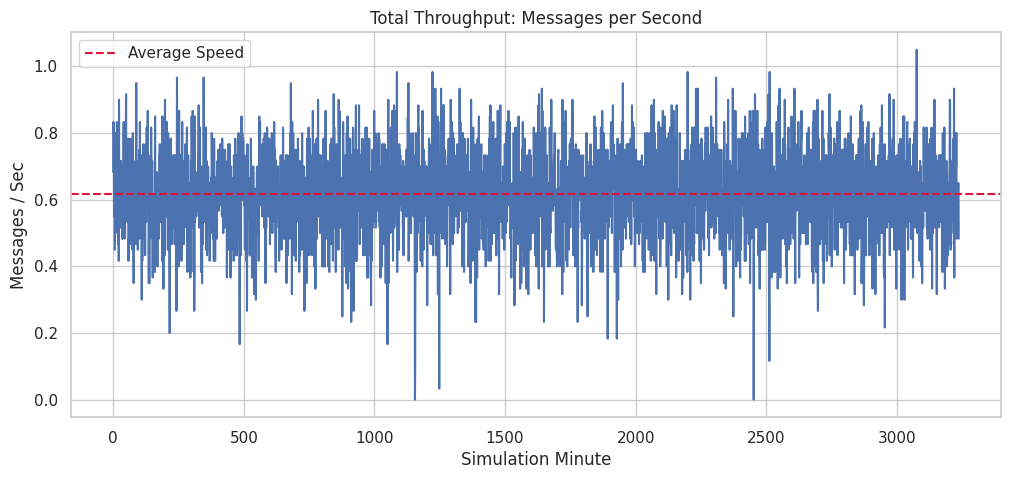

In [104]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=throughput_60s, x="window_minute", y="messages_per_second", ax=ax)
ax.axhline(overall_messages_per_second, color="crimson", linestyle="--", label="Average Speed")
ax.set_title("Total Throughput: Messages per Second")
ax.set_xlabel("Simulation Minute")
ax.set_ylabel("Messages / Sec")
ax.legend()
plt.show()

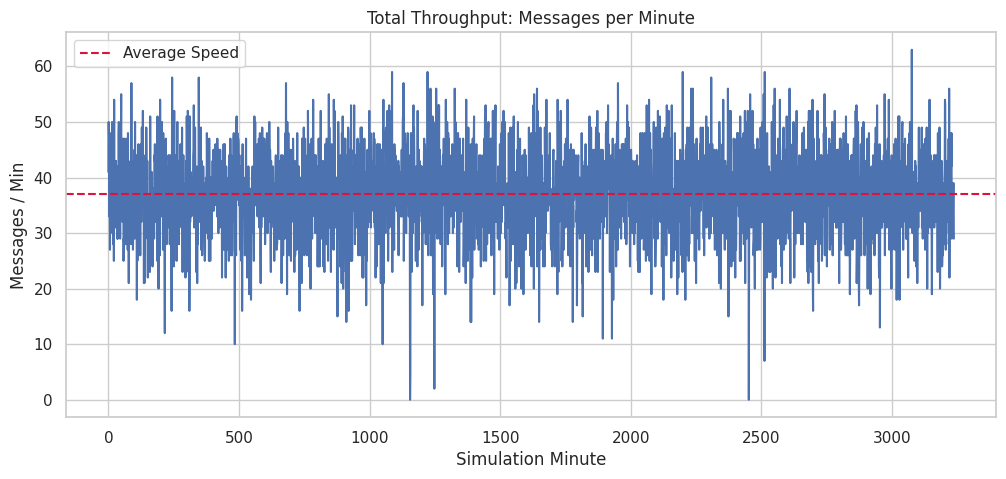

In [105]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=throughput_60s, x="window_minute", y="messages_per_minute", ax=ax)
ax.axhline(overall_messages_per_minute, color="crimson", linestyle="--", label="Average Speed")
ax.set_title("Total Throughput: Messages per Minute")
ax.set_xlabel("Simulation Minute")
ax.set_ylabel("Messages / Min")
ax.legend()
plt.show()

## Throughput by Worker

Each line represents an individual worker. The aggregation window is also 60 seconds.

In [106]:
def build_worker_throughput(results: pd.DataFrame, bin_seconds: int = 60) -> pd.DataFrame:
    max_time = math.ceil(results["finish_time"].max())
    bins = np.arange(0, max_time + bin_seconds, bin_seconds)

    worker_throughput = (
        results.assign(time_bin=pd.cut(results["finish_time"], bins=bins, right=False, include_lowest=True))
        .groupby(["worker_id", "time_bin"], observed=False)
        .size()
        .rename("messages")
        .reset_index()
    )

    worker_throughput["window_start"] = worker_throughput["time_bin"].apply(lambda interval: interval.left).astype(float)
    worker_throughput["window_minute"] = worker_throughput["window_start"] / 60
    worker_throughput["messages_per_second"] = worker_throughput["messages"] / bin_seconds
    worker_throughput["messages_per_minute"] = worker_throughput["messages_per_second"] * 60
    return worker_throughput.drop(columns="time_bin")


worker_throughput_60s = build_worker_throughput(results, bin_seconds=60)
worker_throughput_60s.head()

,worker_id,messages,window_start,window_minute,messages_per_second,messages_per_minute
0,0,41,0.000,0.000,0.683,41.000
1,0,50,60.000,1.000,0.833,50.000
2,0,47,120.000,2.000,0.783,47.000
3,0,33,180.000,3.000,0.550,33.000
4,0,38,240.000,4.000,0.633,38.000


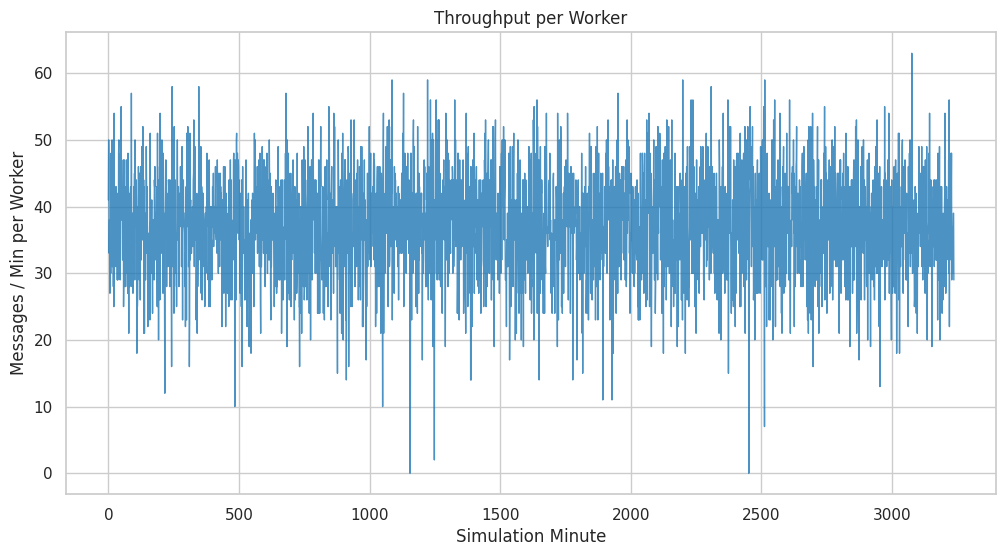

In [107]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(
    data=worker_throughput_60s,
    x="window_minute",
    y="messages_per_minute",
    hue="worker_id",
    palette="tab20",
    linewidth=1,
    alpha=0.8,
    legend=False,
    ax=ax,
)
ax.set_title("Throughput per Worker")
ax.set_xlabel("Simulation Minute")
ax.set_ylabel("Messages / Min per Worker")
plt.show()

## Distribution of Worker Speeds and Processing Times

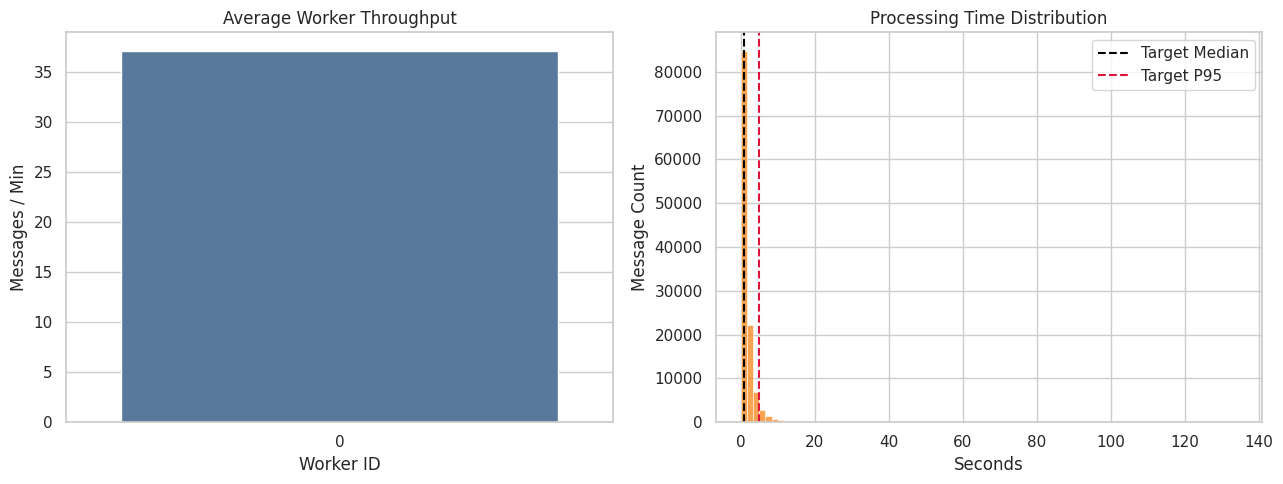

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(
    data=worker_summary,
    x="worker_id",
    y="messages_per_minute_total_window",
    color="#4C78A8",
    ax=axes[0],
)
axes[0].set_title("Average Worker Throughput")
axes[0].set_xlabel("Worker ID")
axes[0].set_ylabel("Messages / Min")

sns.histplot(results["duration"], bins=80, color="#F58518", ax=axes[1])
axes[1].axvline(config.median_seconds, color="black", linestyle="--", label="Target Median")
axes[1].axvline(config.p95_seconds, color="crimson", linestyle="--", label="Target P95")
axes[1].set_title("Processing Time Distribution")
axes[1].set_xlabel("Seconds")
axes[1].set_ylabel("Message Count")
axes[1].legend()

plt.tight_layout()
plt.show()

## Summary Text Output

In [109]:
print(f"Messages processed: {total_messages:,}")
print(f"Total processing time: {total_time_seconds:,.1f} sec = {total_time_minutes:,.1f} min = {total_time_hours:,.2f} h")
print(f"All workers: {overall_messages_per_second:.2f} msg/sec = {overall_messages_per_minute:.1f} msg/min")
print(
    "Single worker average: "
    f"{worker_summary['messages_per_second_total_window'].mean():.3f} msg/sec = "
    f"{worker_summary['messages_per_minute_total_window'].mean():.1f} msg/min"
)

Messages processed: 120,000
Total processing time: 194,261.3 sec = 3,237.7 min = 53.96 h
All workers: 0.62 msg/sec = 37.1 msg/min
Single worker average: 0.618 msg/sec = 37.1 msg/min


## Extended Simulation Comparison

In [110]:
median_p95_pairs_to_test = [
    (1, 3),
    (2, 4),
    (3, 5),
    (4, 6),
]
worker_counts_to_test = [1, 2, 3, 4] # Based on previous examples for 'separate color'

all_comparison_runs = []

for median_s, p95_s in median_p95_pairs_to_test:
    for num_workers in worker_counts_to_test:
        # Create a new SimulationConfig for the current run
        current_config = SimulationConfig(
            messages=config.messages,
            workers=num_workers,
            median_seconds=float(median_s),
            p95_seconds=float(p95_s),
            random_seed=config.random_seed # Keep random seed consistent
        )

        # Recalculate lognormal distribution parameters for the current config
        # These are global variables used by sample_processing_time
        global lognormal_mu, lognormal_sigma
        lognormal_mu = math.log(current_config.median_seconds)
        lognormal_sigma = math.log(current_config.p95_seconds / current_config.median_seconds) / Z95

        print(f"Running simulation for Workers: {current_config.workers}, Median: {current_config.median_seconds}s, P95: {current_config.p95_seconds}s")

        # Run the simulation
        current_results = run_simulation(current_config)

        # Extract total time in hours
        total_time_seconds_current = current_results["finish_time"].max()
        total_time_hours_current = total_time_seconds_current / 3600

        all_comparison_runs.append({
            'workers': current_config.workers,
            'median_seconds': current_config.median_seconds,
            'p95_seconds': current_config.p95_seconds,
            'total_time_hours': total_time_hours_current
        })

extended_comparison_df = pd.DataFrame(all_comparison_runs)
display(extended_comparison_df)


Running simulation for Workers: 1, Median: 1.0s, P95: 3.0s
Running simulation for Workers: 2, Median: 1.0s, P95: 3.0s
Running simulation for Workers: 3, Median: 1.0s, P95: 3.0s
Running simulation for Workers: 4, Median: 1.0s, P95: 3.0s
Running simulation for Workers: 1, Median: 2.0s, P95: 4.0s
Running simulation for Workers: 2, Median: 2.0s, P95: 4.0s
Running simulation for Workers: 3, Median: 2.0s, P95: 4.0s
Running simulation for Workers: 4, Median: 2.0s, P95: 4.0s
Running simulation for Workers: 1, Median: 3.0s, P95: 5.0s
Running simulation for Workers: 2, Median: 3.0s, P95: 5.0s
Running simulation for Workers: 3, Median: 3.0s, P95: 5.0s
Running simulation for Workers: 4, Median: 3.0s, P95: 5.0s
Running simulation for Workers: 1, Median: 4.0s, P95: 6.0s
Running simulation for Workers: 2, Median: 4.0s, P95: 6.0s
Running simulation for Workers: 3, Median: 4.0s, P95: 6.0s
Running simulation for Workers: 4, Median: 4.0s, P95: 6.0s


,workers,median_seconds,p95_seconds,total_time_hours
0,1,1.000,3.000,41.665
1,2,1.000,3.000,20.833
2,3,1.000,3.000,13.888
3,4,1.000,3.000,10.416
4,1,2.000,4.000,72.805
5,2,2.000,4.000,36.403
6,3,2.000,4.000,24.268
7,4,2.000,4.000,18.201
8,1,3.000,5.000,104.864
9,2,3.000,5.000,52.432


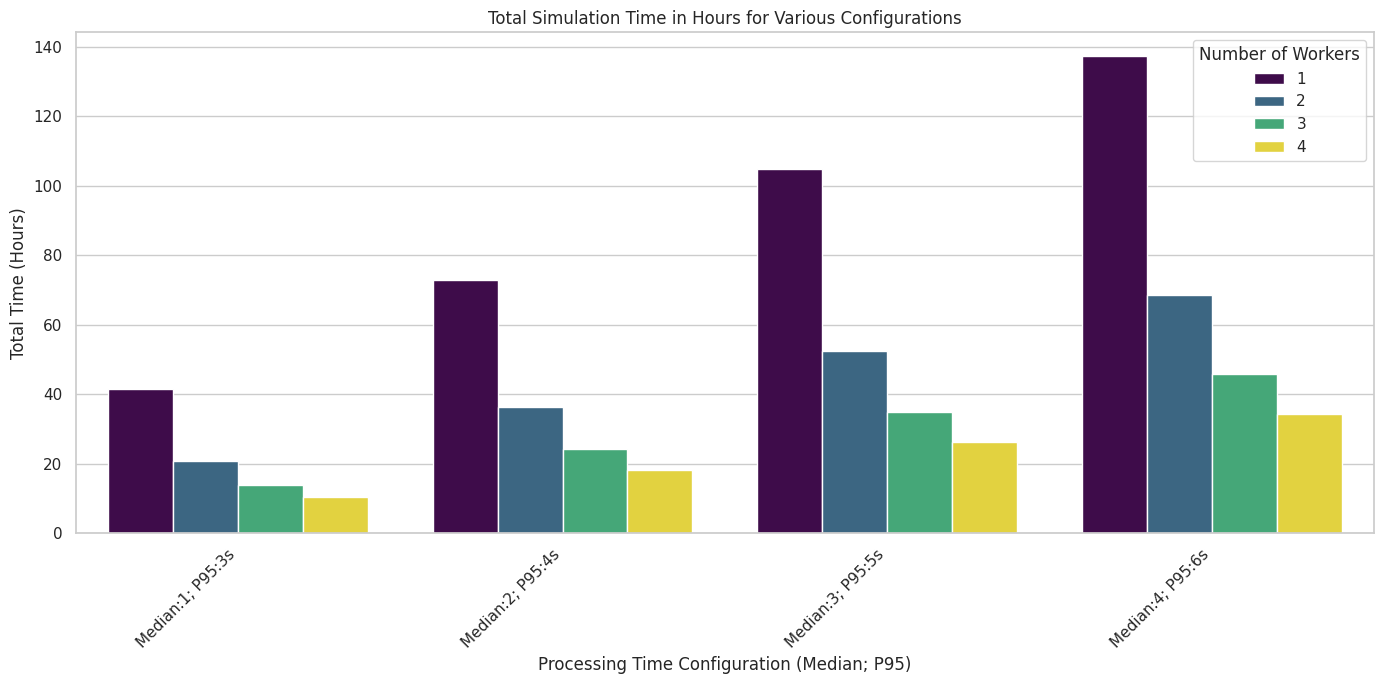

In [111]:
# Create a combined label for the x-axis
extended_comparison_df['run_label'] = extended_comparison_df.apply(
    lambda row: f"Median:{int(row['median_seconds'])}; P95:{int(row['p95_seconds'])}s", axis=1
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(x='run_label', y='total_time_hours', hue='workers', data=extended_comparison_df, ax=ax, palette='viridis')
ax.set_title('Total Simulation Time in Hours for Various Configurations')
ax.set_xlabel('Processing Time Configuration (Median; P95)')
ax.set_ylabel('Total Time (Hours)')
ax.legend(title='Number of Workers')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()
